In [1]:
import sys; sys.path.append("../src")
import numpy as np, pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error
from load_data import load_cells

In [2]:
# --- data ---
BASE = "../data/raw/Battery_DataSet/Battery_DataSet"
paths = {b: f"{BASE}/{b}.mat" for b in ["B0005", "B0006", "B0007", "B0018"]}
df = load_cells(paths)

FEATURES = ["v_mean", "v_min", "temp_max"]   # per-step summaries
TARGET   = "soh"

In [3]:
def make_model():
    # scale features, then ridge. scaling matters because our features are on
    # different scales (volts vs degrees) + ridge's penalty assumes comparable scales.
    return make_pipeline(StandardScaler(), Ridge(alpha=1.0))

In [4]:
# --- EVAL 1: the naive (leaky) way: random split of ROWS ---
def eval_random_split(df, n_repeats=20, test_frac=0.2, seed=0):
    rng = np.random.default_rng(seed)
    errs = []
    for _ in range(n_repeats):
        idx = rng.permutation(len(df))                 # shuffle all rows
        cut = int(len(df) * (1 - test_frac))
        tr, te = df.iloc[idx[:cut]], df.iloc[idx[cut:]]
        model = make_model().fit(tr[FEATURES], tr[TARGET])
        errs.append(mean_absolute_error(te[TARGET], model.predict(te[FEATURES])))
    return np.mean(errs)                                # avg MAE over repeats

In [5]:
# --- EVAL 2: the honest way — hold out a WHOLE CELL ---
def eval_leave_one_cell_out(df):
    per_cell = {}
    for held_out in df["cell_id"].unique():
        tr = df[df["cell_id"] != held_out]             # train on the other cells
        te = df[df["cell_id"] == held_out]             # test on the unseen cell
        model = make_model().fit(tr[FEATURES], tr[TARGET])
        per_cell[held_out] = mean_absolute_error(te[TARGET], model.predict(te[FEATURES]))
    return per_cell

In [6]:
random_mae = eval_random_split(df)
loco = eval_leave_one_cell_out(df)

print(f"Random split (leaky)      MAE: {random_mae:.4f} SOH")
print(f"Leave-one-cell-out (honest):")
for cell, e in loco.items():
    print(f"    hold out {cell}:  MAE {e:.4f}")
print(f"    mean:  {np.mean(list(loco.values())):.4f}")
print(f"    worst: {np.max(list(loco.values())):.4f}  <- {max(loco, key=loco.get)}")
print(f"\nHonest error is ~{np.mean(list(loco.values()))/random_mae:.1f}x the leaky estimate")

Random split (leaky)      MAE: 0.0217 SOH
Leave-one-cell-out (honest):
    hold out B0005:  MAE 0.0301
    hold out B0006:  MAE 0.0479
    hold out B0007:  MAE 0.0269
    hold out B0018:  MAE 0.0236
    mean:  0.0321
    worst: 0.0479  <- B0006

Honest error is ~1.5x the leaky estimate


## Plotting!

In [7]:
import matplotlib.pyplot as plt

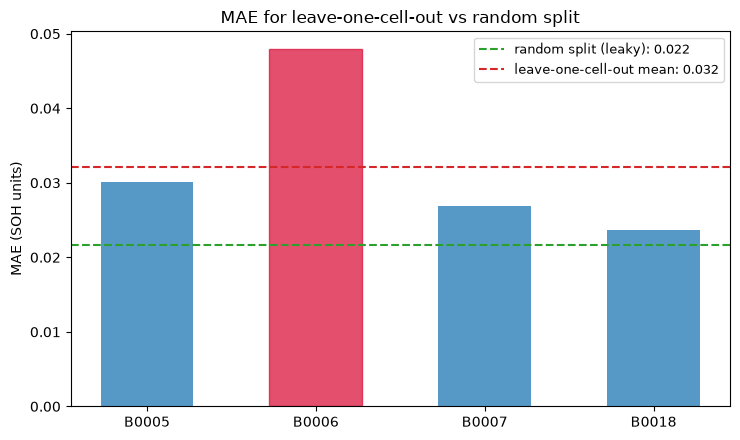

In [10]:
cells = list(loco.keys())
cell_errs = list(loco.values())
loco_mean = np.mean(cell_errs)

fig, ax = plt.subplots(figsize=(7.5, 4.5))

# the two honest reference lines vs the leaky one
ax.axhline(random_mae, ls="--", color="tab:green",
           label=f"random split (leaky): {random_mae:.3f}")
ax.axhline(loco_mean, ls="--", color="tab:red",
           label=f"leave-one-cell-out mean: {loco_mean:.3f}")

# per-cell honest errors as bars
bars = ax.bar(cells, cell_errs, color="tab:blue", alpha=0.75, width=0.55)
bars[int(np.argmax(cell_errs))].set_color("crimson")   # highlight the worst cell

ax.set_ylabel("MAE (SOH units)")
ax.set_title("MAE for leave-one-cell-out vs random split")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("../figures/eval_gap.png", dpi=130)
plt.show()